# Phase II: EDA on CNN/DailyMail Dataset

This notebook performs exploratory data analysis on the CNN/DailyMail dataset for text summarization.

In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os

c:\Users\My Device\Desktop\Text Summarization Using Pre-trained Models\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_config():
    with open('../config.yaml', 'r') as f:
        return yaml.safe_load(f)

config = load_config()
print("Config loaded successfully.")

Config loaded successfully.


In [3]:
def load_summarization_data(config):
    """Load dataset from Hugging Face based on config."""
    print(f"Loading {config['data']['dataset_name']} dataset...")
    dataset = load_dataset(
        config['data']['dataset_name'], 
        config['data']['dataset_config']
    )
    return dataset

datasets = load_summarization_data(config)
print("Dataset loaded successfully.")
print(datasets)

Loading cnn_dailymail dataset...


c:\Users\My Device\Desktop\Text Summarization Using Pre-trained Models\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\My Device\.cache\huggingface\hub\datasets--cnn_dailymail. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 11490/11490 [00:00<00:00, 16988.3

Dataset loaded successfully.
DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})


In [5]:
# Convert a subset to pandas for EDA
train_df = pd.DataFrame(datasets['train'].select(range(5000)))
print("Training Data Subset (First 5000 samples):")
print(train_df.info())

Training Data Subset (First 5000 samples):
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   article     5000 non-null   str  
 1   highlights  5000 non-null   str  
 2   id          5000 non-null   str  
dtypes: str(3)
memory usage: 19.0 MB
None


In [6]:
# Analyze article and highlights (summary) lengths
train_df['article_len'] = train_df['article'].apply(lambda x: len(x.split()))
train_df['highlights_len'] = train_df['highlights'].apply(lambda x: len(x.split()))

print("\nArticle Length Stats (words):")
print(train_df['article_len'].describe())

print("\nHighlights Length Stats (words):")
print(train_df['highlights_len'].describe())


Article Length Stats (words):
count    5000.000000
mean      615.214200
std       302.232465
min        18.000000
25%       376.000000
50%       570.000000
75%       816.250000
max      1831.000000
Name: article_len, dtype: float64

Highlights Length Stats (words):
count    5000.000000
mean       43.888800
std         7.734546
min        11.000000
25%        38.000000
50%        45.000000
75%        50.000000
max        75.000000
Name: highlights_len, dtype: float64


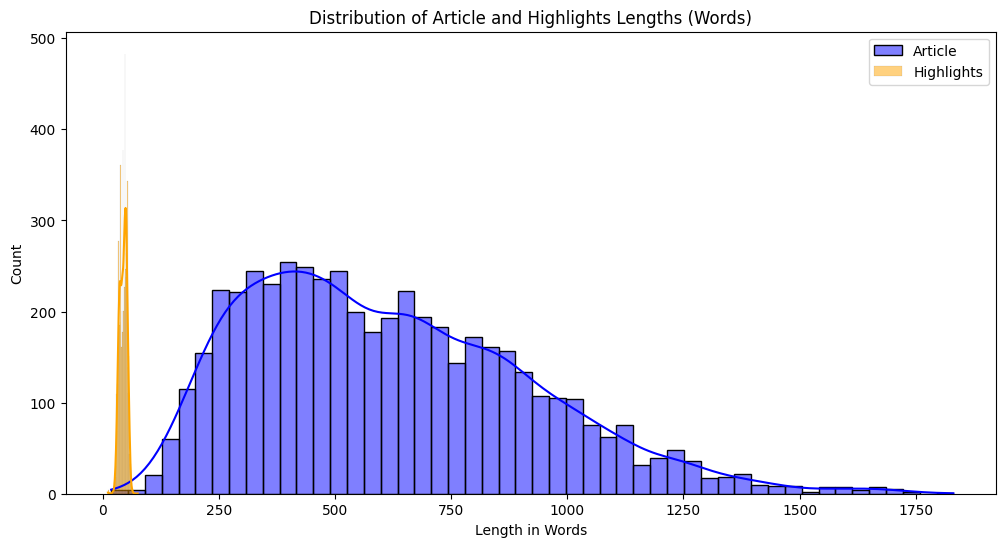

In [7]:
# Visualize distributions
plt.figure(figsize=(12, 6))
sns.histplot(train_df['article_len'], bins=50, kde=True, color='blue', label='Article')
sns.histplot(train_df['highlights_len'], bins=50, kde=True, color='orange', label='Highlights')
plt.title('Distribution of Article and Highlights Lengths (Words)')
plt.xlabel('Length in Words')
plt.ylabel('Count')
plt.legend()
plt.show()